In [ ]:
#I used numpy, pandas, and matplotlib.
#Numpy was to handle the numbers of the data. It also allowed me to do the log transformations.
#Pandas was to handle the data as a dataframe. 
#Matplotlib was to create the graphs and plots that I did.

In [7]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Read data
df = pd.read_csv("UC_CK_CD.csv")
df = df.set_index('Unnamed: 0')

#Clean the condition names to capitalize and get rid of _
clean_names = {'Control_samples': 'Control Samples','Ulcerative_colitis': 'Ulcerative Colitis', 'Chrons_Disease': "Crohn's Disease"}
df['Condition'] = df['Condition'].replace(clean_names)

Text(0, 0.5, 'Number of Cells')

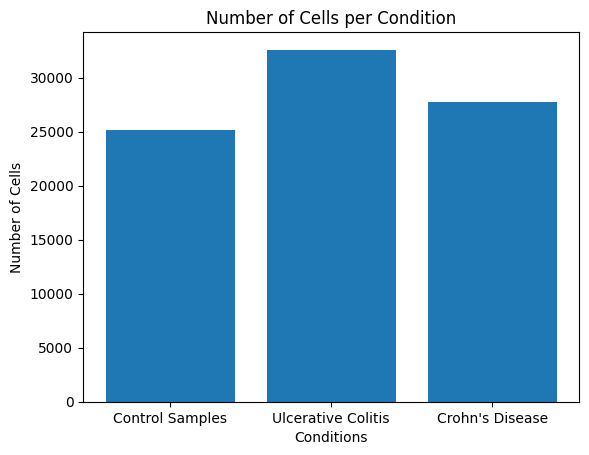

In [2]:
###------Bar plot of number of cells per condition------###
condition_types = df['Condition'].unique()
condition_type_counts = []
for i in condition_types:
    sub_data_conditions = df[df['Condition'] == i]

    result = len(sub_data_conditions)
    condition_type_counts.append(result)
condition_type_counts

plt.bar(condition_types, condition_type_counts)
plt.title('Number of Cells per Condition')
plt.xlabel('Conditions')
plt.ylabel('Number of Cells')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'CK118'),
  Text(1, 0, 'CK119'),
  Text(2, 0, 'CK254'),
  Text(3, 0, 'CK258'),
  Text(4, 0, 'UC133_2'),
  Text(5, 0, 'UC141'),
  Text(6, 0, 'UC287'),
  Text(7, 0, 'UC309'),
  Text(8, 0, 'CD134-2'),
  Text(9, 0, 'CD139'),
  Text(10, 0, 'CD293'),
  Text(11, 0, 'CD303')])

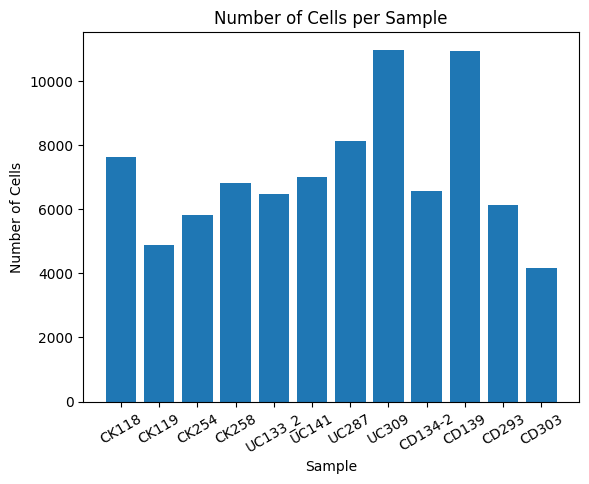

In [4]:
###------Bar plot of number of cells per sample------###
sample_types = df['Sample'].unique()
sample_type_counts = []
for x in sample_types:
    sub_data_samples = df[df['Sample'] == x]
    result = len(sub_data_samples)
    sample_type_counts.append(result)

plt.bar(sample_types, sample_type_counts)
plt.title('Number of Cells per Sample')
plt.xlabel('Sample')
plt.ylabel('Number of Cells')
plt.xticks(rotation=30)

/var/folders/pf/hx6jr_d169b0kwptq4176yj80000gn/T/ipykernel_25782/932841604.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Total_CD_RNA'] = df[cd_genes].sum(axis=1)
/var/folders/pf/hx6jr_d169b0kwptq4176yj80000gn/T/ipykernel_25782/932841604.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Log1p_Total_CD_RNA'] = np.log1p(df['Total_CD_RNA'])


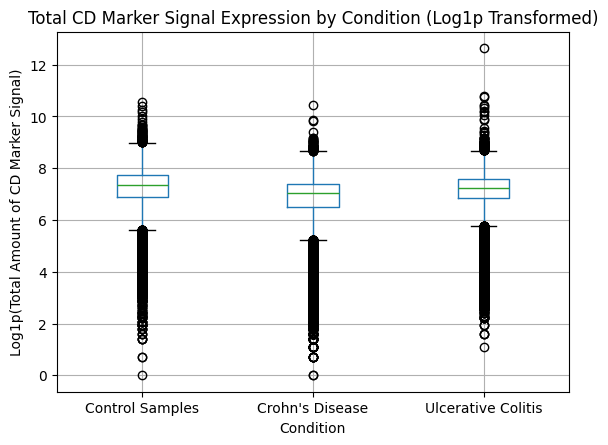

In [8]:
####------Boxplot with log-transformed CD data------###

#Total amount of RNA in cells by condition
#Get the column names for columns 3 through 433
target_cols = df.columns[3:434]

# Group by condition and sum those columns
RNA_counts = df.groupby('Condition')[target_cols].sum()

#Find all columns (genes) that start with 'CD'
cd_genes = [col for col in df.columns if col.startswith('CD')]

#Sum the values of all CD genes for each cell (row-wise)
df['Total_CD_RNA'] = df[cd_genes].sum(axis=1)

#log1p transformation to the column
df['Log1p_Total_CD_RNA'] = np.log1p(df['Total_CD_RNA'])

df.boxplot(column='Log1p_Total_CD_RNA', by='Condition', rot=0)

plt.title('Total CD Marker Signal Expression by Condition (Log1p Transformed)')
plt.suptitle('') 
plt.ylabel('Log1p(Total Amount of CD Marker Signal)')
plt.show()

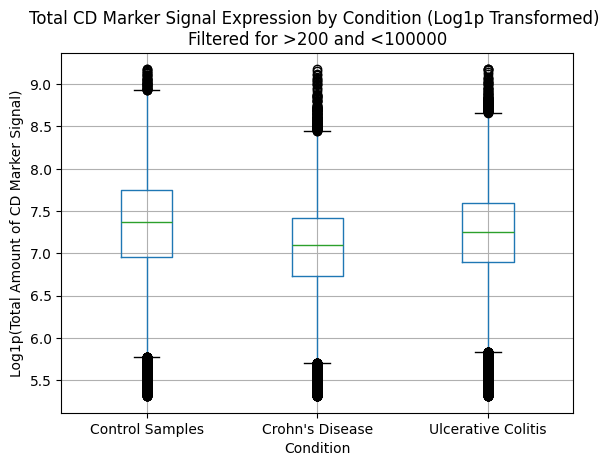

In [10]:
####------Boxplot with log-transformed CD data, filtered >200 and <100000------###
filter2 = df['Total_CD_RNA']<10000
filter3 = df['Total_CD_RNA']>200
df = df[filter2 & filter3]

#log1p transformation to the column
df['Log1p_Total_CD_RNA'] = np.log1p(df['Total_CD_RNA'])

df.boxplot(column='Log1p_Total_CD_RNA', by='Condition', rot=0)

plt.title('Total CD Marker Signal Expression by Condition (Log1p Transformed) \nFiltered for >200 and <100000')
plt.suptitle('') 
plt.ylabel('Log1p(Total Amount of CD Marker Signal)')
plt.show()

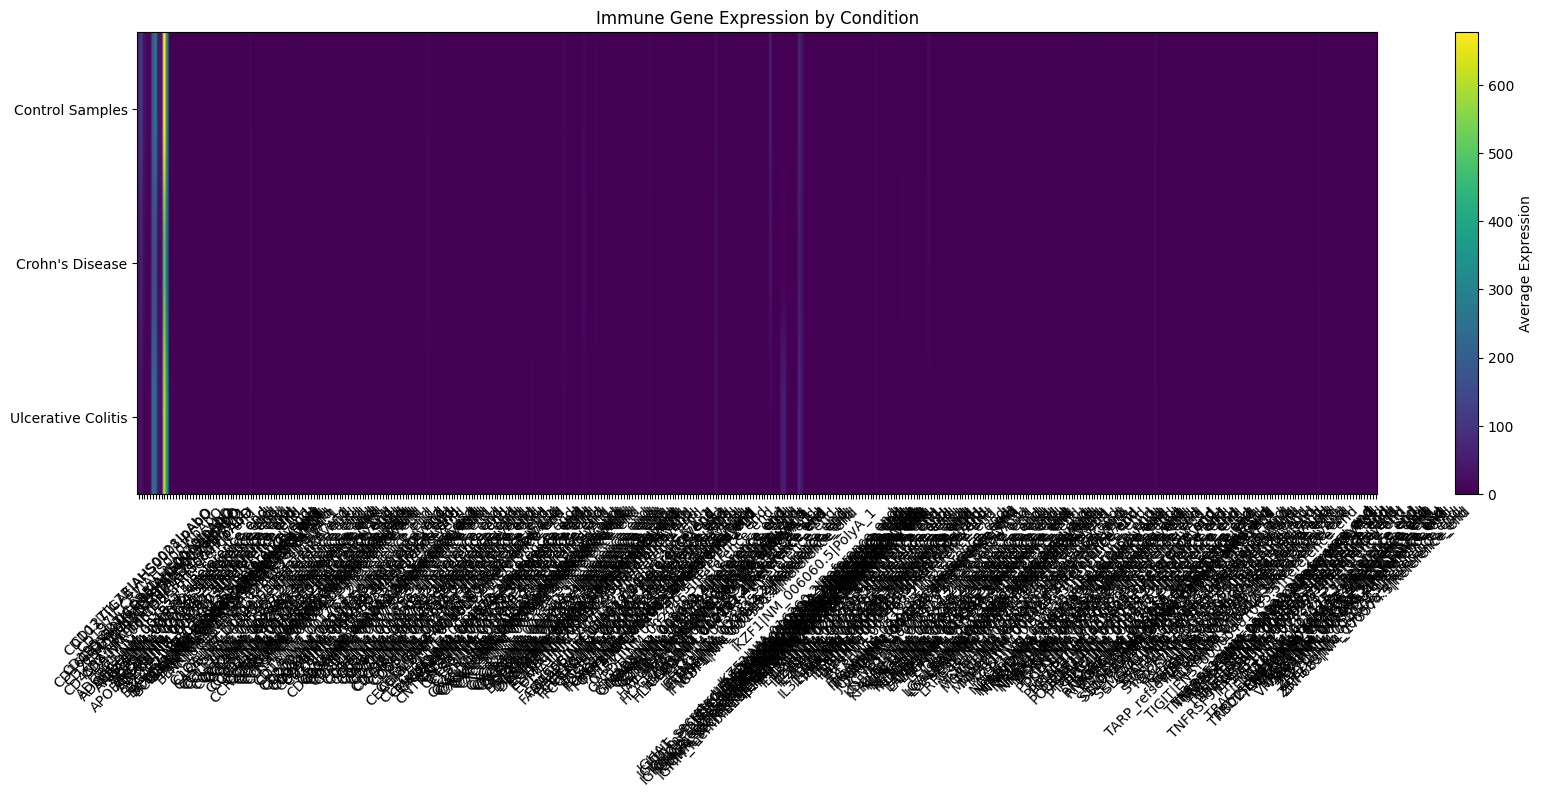

In [31]:
###------Heatmap of all gene expression by condition------###
#Import packages and read data
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("UC_CK_CD.csv")

#Clean the condition names to capitalize and get rid of _
clean_names = {'Control_samples': 'Control Samples','Ulcerative_colitis': 'Ulcerative Colitis', 'Chrons_Disease': "Crohn's Disease"}
df['Condition'] = df['Condition'].replace(clean_names)

genes = list(df)
genes.remove('Unnamed: 0')
genes.remove('Sample')
genes.remove('Condition')
genes.remove('Cell_Index')

# Average by condition
heatmap_data = df.groupby('Condition')[genes].mean()

# Plot heatmap
plt.figure(figsize=(20,6))
plt.imshow(heatmap_data, aspect='auto')
plt.colorbar(label='Average Expression')
plt.xticks(range(len(genes)), genes, rotation=45)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.title('Immune Gene Expression by Condition')
plt.show()

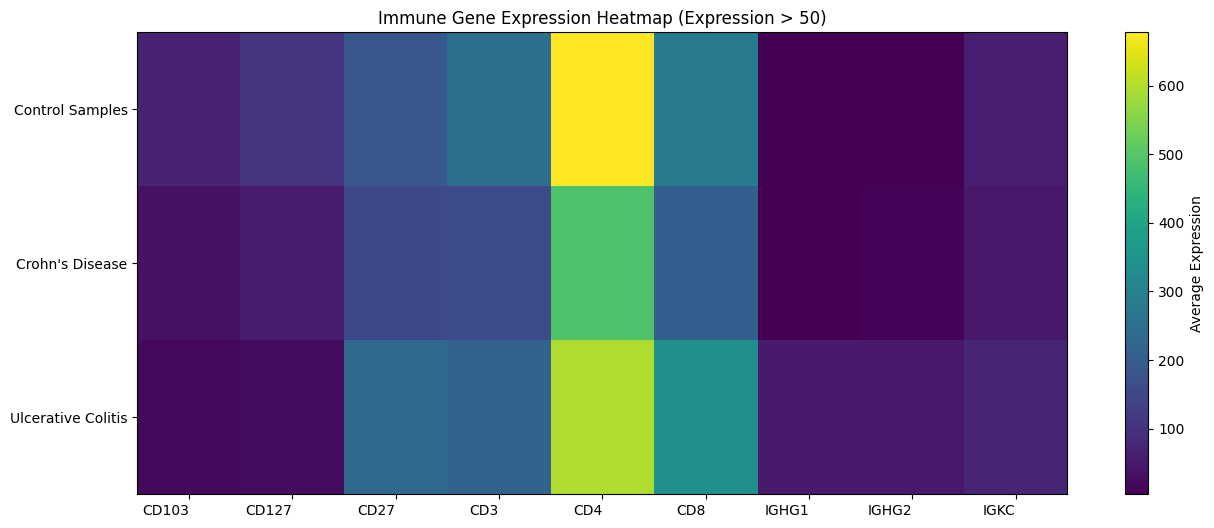

In [33]:
###------Heatmap of gene expression >50 by condition------###

#ilter to keep only genes with max expression > 50
filtered_heatmap_data = heatmap_data.loc[:, (heatmap_data > 50).any()]
filtered_names = ("CD103", "CD127", "CD27", "CD3", "CD4", "CD28", "IGHG1", "IGHG2", "IGKC")

plt.figure(figsize=(15, 6))
plt.imshow(filtered_heatmap_data, aspect='auto')
plt.colorbar(label='Average Expression')
plt.xticks(range(len(filtered_heatmap_data.columns)), filtered_names, rotation=0, ha='right')
plt.yticks(range(len(filtered_heatmap_data.index)), filtered_heatmap_data.index)
plt.title('Immune Gene Expression Heatmap (Expression > 50)')
plt.show()

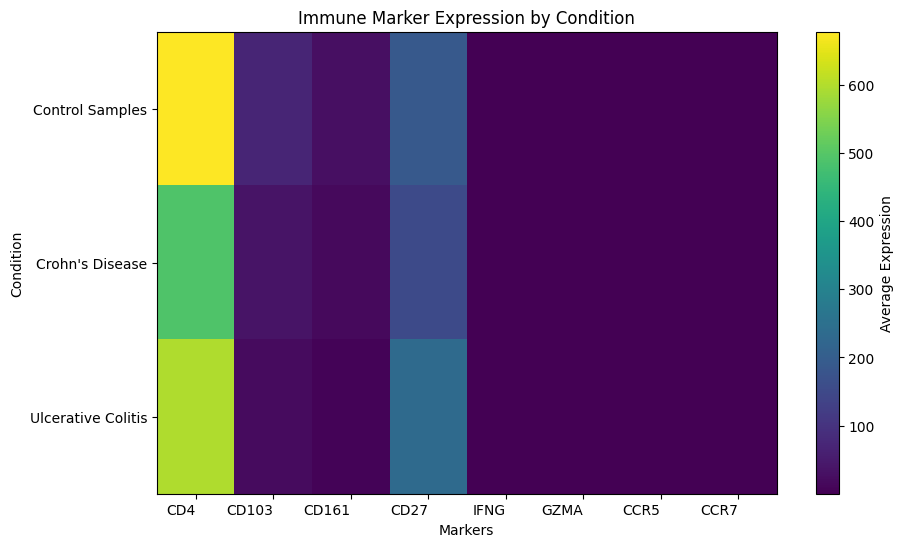

In [26]:
###------Heatmap for marker expression by condition------###
genes = list(df)
genes.remove('Sample')
genes.remove('Condition')
genes.remove('Cell_Index')

markers = {'CD4': 'CD4:SK3|CD4|AHS0032|pAbO',
           "CD103": 'CD103|ITGAE|AHS0001|pAbO',
           "CD161": 'CD161:DX12|KLRB1|AHS0002|pAbO',
            "CD27": 'CD27:M-T271|CD27|AHS0025|pAbO',
           "IFNG": 'IFNG|NM_000619.2|Reference_end',
           "GZMA": 'GZMA|NM_006144.3|Reference_end',
           "CCR5":'CCR5|NM_000579.3|Reference_end',
           "CCR7": 'CCR7|NM_001838.3|Reference_end'}

#Averaged heatmap data
heatmap_data = df.groupby("Condition")[list(markers.values())].mean()
#Rename columns
heatmap_data.columns = list(markers.keys())
#Replace NaNs
heatmap_data = heatmap_data.fillna(0)

# Plotting the heatmap
plt.figure(figsize=(10, 6))

im = plt.imshow(heatmap_data.values, aspect='auto',cmap='viridis')

plt.colorbar(im, label='Average Expression')

plt.xticks(np.arange(len(heatmap_data.columns)),heatmap_data.columns,rotation=0,ha='right')

plt.yticks(np.arange(len(heatmap_data.index)), heatmap_data.index)

plt.title("Immune Marker Expression by Condition")
plt.xlabel("Markers")
plt.ylabel("Condition")
plt.show()

/var/folders/pf/hx6jr_d169b0kwptq4176yj80000gn/T/ipykernel_25782/3799888692.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Log1p_CD4_Expression'] = np.log1p(df['CD4:SK3|CD4|AHS0032|pAbO'])


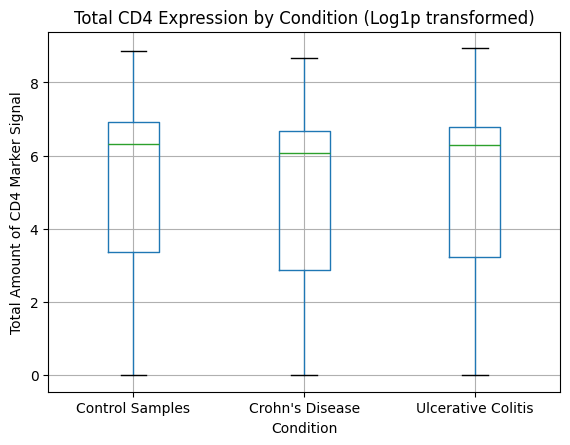

In [30]:
###------Boxplot of CD4 expression by condition (log-transformed)------###
#log1p transformation on the CD4 column
df['Log1p_CD4_Expression'] = np.log1p(df['CD4:SK3|CD4|AHS0032|pAbO'])

df.boxplot(column='Log1p_CD4_Expression', by='Condition', rot=0)

plt.title('Total CD4 Expression by Condition (Log1p transformed)')
plt.suptitle('') 
plt.ylabel('Total Amount of CD4 Marker Signal')
plt.show()

/var/folders/pf/hx6jr_d169b0kwptq4176yj80000gn/T/ipykernel_25782/33043575.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Log1p_CD27_Expression'] = np.log1p(df['CD27:M-T271|CD27|AHS0025|pAbO'])


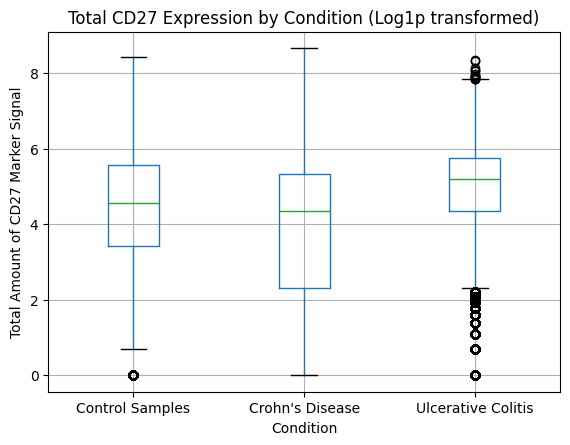

In [34]:
###------Boxplot of CD27 expression by condition (log-transformed)------###

#log1p transformation on the CD27 column
df['Log1p_CD27_Expression'] = np.log1p(df['CD27:M-T271|CD27|AHS0025|pAbO'])

df.boxplot(column='Log1p_CD27_Expression', by='Condition', rot=0)

plt.title('Total CD27 Expression by Condition (Log1p transformed)')
plt.suptitle('') 
plt.ylabel('Total Amount of CD27 Marker Signal')
plt.show()

/var/folders/pf/hx6jr_d169b0kwptq4176yj80000gn/T/ipykernel_25782/266788714.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Log1p_CD28_Expression'] = np.log1p(df['CD28|ENST00000374481.7|PolyA_1'])


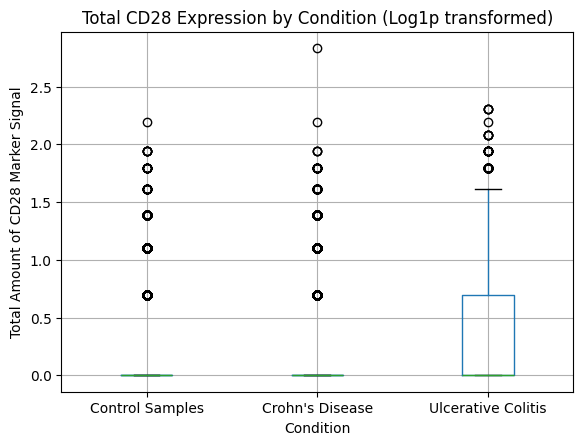

In [35]:
###------Boxplot of CD28 expression by condition (log-transformed)------###

#log1p transformation on the CD28 column
df['Log1p_CD28_Expression'] = np.log1p(df['CD28|ENST00000374481.7|PolyA_1'])

df.boxplot(column='Log1p_CD28_Expression', by='Condition', rot=0)

plt.title('Total CD28 Expression by Condition (Log1p transformed)')
plt.suptitle('') 
plt.ylabel('Total Amount of CD28 Marker Signal')
plt.show()